# Run Analysis 

Self-contained walkthrough of the batch analysis that was in `run_analysis.py`: runs scenarios, shows summaries, plots time series, distributions, and a patch/spread heatmap.

In [11]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Sequence, Tuple, Type

import matplotlib.pyplot as plt
import pandas as pd

from models import UniversityNetwork

%matplotlib inline

@dataclass(frozen=True)
class Scenario:
    name: str
    patching_rate: float
    virus_spread_chance: float
    num_agents: int = 500
    initial_outbreak_size: int = 10
    avg_incubation_time: float = 4.0

@dataclass(frozen=True)
class ModelSpec:
    name: str
    model_cls: Type

SCENARIOS: List[Scenario] = [
    Scenario('A: Low Patch, High Spread', patching_rate=0.05, virus_spread_chance=0.4),
    Scenario('B: High Patch, High Spread', patching_rate=0.10, virus_spread_chance=0.4),
    Scenario('C: Low Patch, Low Spread', patching_rate=0.05, virus_spread_chance=0.2),
]

MODEL_SPECS: List[ModelSpec] = [ModelSpec('Improved', UniversityNetwork)]

def _run_single(model_spec: ModelSpec, scenario: Scenario, max_steps: int = 300, seed: int | None = None) -> pd.DataFrame:
    model = model_spec.model_cls(
        virus_spread_chance=scenario.virus_spread_chance,
        patching_rate=scenario.patching_rate,
        num_agents=scenario.num_agents,
        initial_outbreak_size=scenario.initial_outbreak_size,
        avg_incubation_time=scenario.avg_incubation_time,
        seed=seed,
    )
    health_enum = model.schedule.agents[0].state.__class__
    for _ in range(max_steps):
        infected = model.count_state(health_enum.INFECTED)
        exposed = model.count_state(health_enum.EXPOSED)
        if infected == 0 and exposed == 0:
            break
        model.step()
    history = model.datacollector.get_model_vars_dataframe()
    return history

def _summarize_history(history: pd.DataFrame, scenario: Scenario, model_spec: ModelSpec, run_idx: int) -> Dict:
    return {
        'Model': model_spec.name,
        'Scenario': scenario.name,
        'Run': run_idx,
        'PeakInfection': float(history['Infected'].max()),
        'PeakDay': int(history['Infected'].idxmax()),
        'Duration': len(history),
        'AreaInfected': float(history['Infected'].sum()),
        'FinalRecovered': float(history['Recovered'].iloc[-1]),
    }

def run_batch(model_spec: ModelSpec, scenario: Scenario, iterations: int = 10, max_steps: int = 300, seed_offset: int = 0) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rows: List[Dict] = []
    first_history: pd.DataFrame | None = None
    for run_idx in range(1, iterations + 1):
        history = _run_single(model_spec, scenario, max_steps=max_steps, seed=seed_offset + run_idx)
        if first_history is None:
            first_history = history
        rows.append(_summarize_history(history, scenario, model_spec, run_idx))
    metrics = pd.DataFrame(rows)
    return metrics, first_history if first_history is not None else pd.DataFrame()

def plot_time_series(history: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(10, 5))
    color_lookup = {'Susceptible': '#2ecc71', 'Exposed': '#f1c40f', 'Infected': '#e74c3c', 'Recovered': '#95a5a6'}
    for column, color in color_lookup.items():
        if column in history.columns:
            plt.plot(history.index, history[column], label=column, color=color, linewidth=2)
    plt.xlabel('Day')
    plt.ylabel('Number of Computers')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_boxplots(results: pd.DataFrame) -> None:
    if results.empty:
        return
    results = results.copy()
    results['Label'] = results['Scenario'] + ' / ' + results['Model']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    results.boxplot(column='PeakInfection', by='Label', rot=45, ax=axes[0])
    axes[0].set_title('Peak Infection Distribution')
    axes[0].set_ylabel('Peak Infected Count')
    results.boxplot(column='Duration', by='Label', rot=45, ax=axes[1])
    axes[1].set_title('Outbreak Duration Distribution')
    axes[1].set_ylabel('Days Until Extinction')
    fig.suptitle('')
    plt.tight_layout()
    plt.show()

def plot_scatter(results: pd.DataFrame) -> None:
    if results.empty:
        return
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = {'Improved': '#2980b9'}
    for model_name, group in results.groupby('Model'):
        ax.scatter(group['Duration'], group['PeakInfection'], label=model_name, alpha=0.7, color=colors.get(model_name))
    ax.set_xlabel('Duration (days)')
    ax.set_ylabel('Peak Infection')
    ax.set_title('Outbreak Duration vs Peak Infection')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

def sweep_grid(model_spec: ModelSpec, patch_values: Sequence[float], spread_values: Sequence[float], iterations: int = 5, max_steps: int = 200) -> pd.DataFrame:
    rows: List[Dict] = []
    for patch in patch_values:
        for spread in spread_values:
            scenario = Scenario('Grid', patching_rate=patch, virus_spread_chance=spread, num_agents=400)
            metrics, _ = run_batch(model_spec, scenario, iterations=iterations, max_steps=max_steps)
            rows.append({
                'Model': model_spec.name,
                'PatchingRate': patch,
                'VirusSpreadChance': spread,
                'AvgPeakInfection': metrics['PeakInfection'].mean(),
            })
    return pd.DataFrame(rows)

def plot_heatmap(grid_results: pd.DataFrame) -> None:
    if grid_results.empty:
        return
    pivot = grid_results.pivot(index='PatchingRate', columns='VirusSpreadChance', values='AvgPeakInfection')
    plt.figure(figsize=(8, 5))
    plt.imshow(pivot, origin='lower', cmap='inferno', aspect='auto')
    plt.colorbar(label='Avg Peak Infection')
    plt.xticks(range(len(pivot.columns)), [f'{v:.2f}' for v in pivot.columns])
    plt.yticks(range(len(pivot.index)), [f'{v:.2f}' for v in pivot.index])
    plt.xlabel('Virus Spread Chance')
    plt.ylabel('Patching Rate')
    plt.title('Peak Infection Heatmap (Improved Model)')
    plt.tight_layout()
    plt.show()


## Batch runs and summary
Runs the improved model across scenarios A/B/C, aggregates metrics, and shows averages.

In [12]:
all_results: List[pd.DataFrame] = []
sample_histories: Dict[str, pd.DataFrame] = {}

for model_spec in MODEL_SPECS:
    for scenario in SCENARIOS:
        metrics, first_history = run_batch(model_spec, scenario, iterations=10, max_steps=250)
        all_results.append(metrics)
        sample_histories[f'{model_spec.name} - {scenario.name}'] = first_history

combined = pd.concat(all_results, ignore_index=True)
combined['Label'] = combined['Scenario'] + ' / ' + combined['Model']

summary = (
    combined.groupby(['Model', 'Scenario'])[['PeakInfection', 'Duration', 'AreaInfected']]
    .mean()
    .rename(columns={'PeakInfection': 'Avg Peak', 'Duration': 'Avg Duration', 'AreaInfected': 'Avg Area'})
    )
summary

Avg Peak  Avg Duration  Avg Area
Model    Scenario                                                    
Improved A: Low Patch, High Spread      346.8         251.0   10979.0
         B: High Patch, High Spread     254.1         251.0    5438.6
         C: Low Patch, Low Spread       315.3         251.0   10942.9

## Time series (sample run)
S/E/I/R trajectory for the improved model under Scenario A (Low Patch, High Spread).

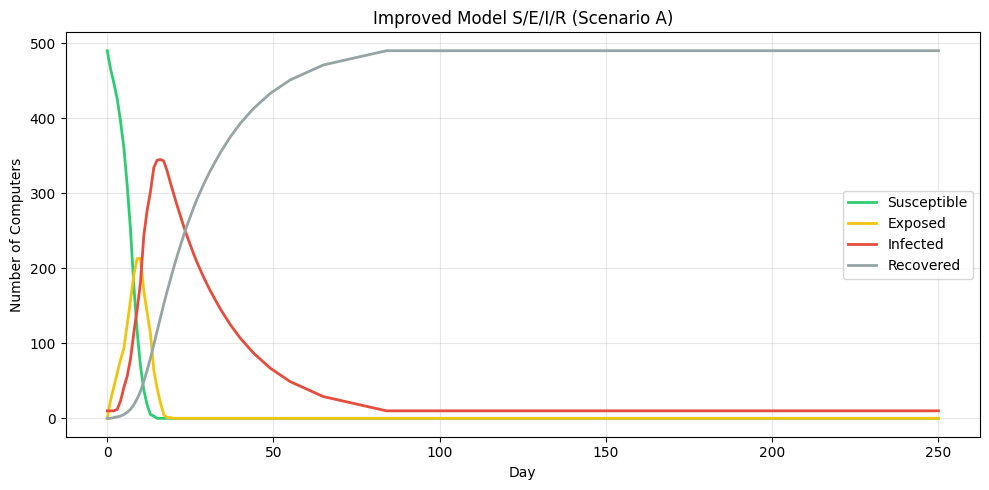

In [13]:
improved_history = sample_histories.get('Improved - A: Low Patch, High Spread')
if improved_history is not None and not improved_history.empty:
    plot_time_series(improved_history, 'Improved Model S/E/I/R (Scenario A)')
else:
    print('No history available for Scenario A.')


## Distributions across runs
Peak infection and outbreak duration variability across scenarios/models.

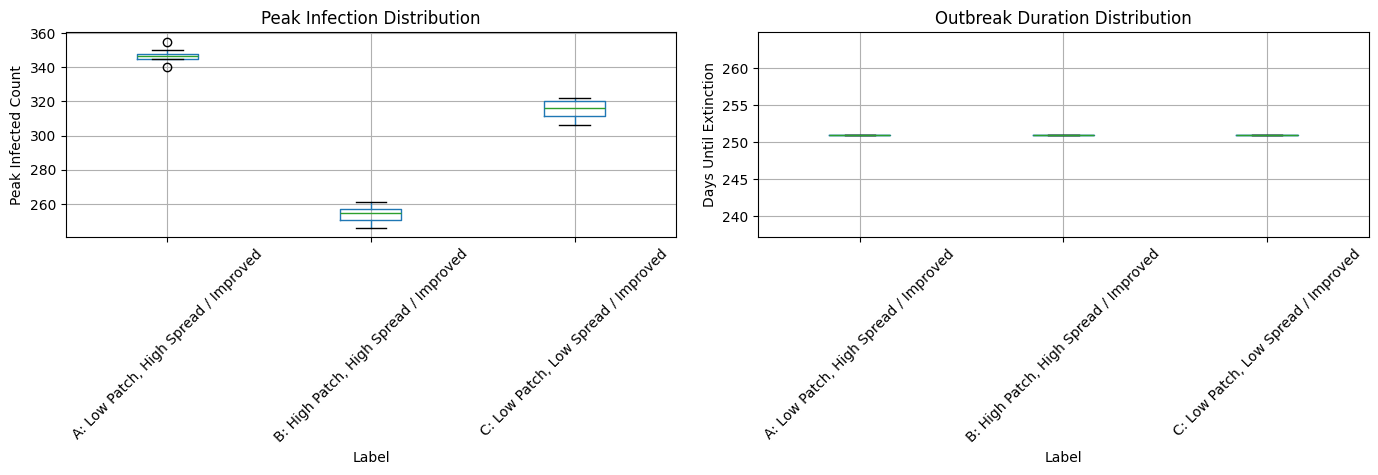

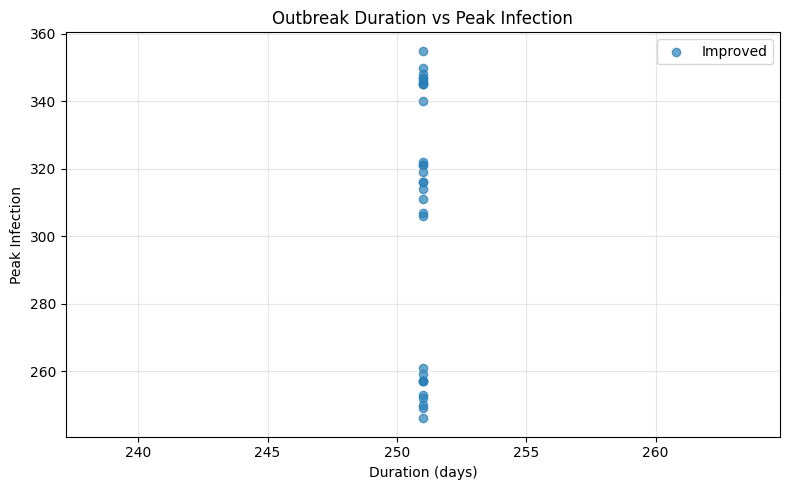

In [14]:
plot_boxplots(combined)
plot_scatter(combined)


## Patch vs spread sensitivity (heatmap)
Grid sweep showing average peak infection across patching rates and spread chances for the improved model.

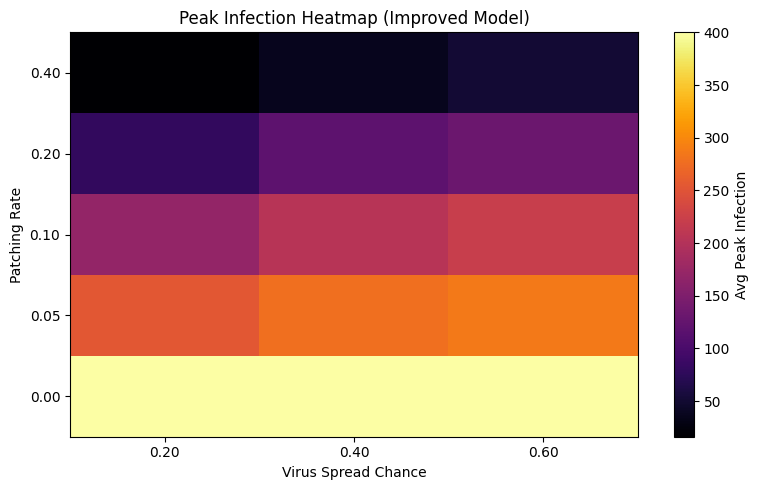

In [15]:
patch_values = [0.0, 0.05, 0.1, 0.2, 0.4]
spread_values = [0.2, 0.4, 0.6]
heatmap_df = sweep_grid(MODEL_SPECS[0], patch_values, spread_values, iterations=4, max_steps=180)
plot_heatmap(heatmap_df)
